In [ ]:
import cairosvg
cairosvg.svg2png(url="train/masks_val/61620A_IP_09_53x35_03_mask.svg", write_to="train/masks_val/61620A_IP_09_53x35_03_mask.png")

# For converting .svg masks to workable .png masks for pytorch

In [ ]:
# Once only preprocessing script, if necessary

import os
import cv2

images_dir = "train/images"
masks_dir = "train/masks"

# Loop through each .tif file to confirm mask exists and has correct dimensions
for fname in os.listdir(images_dir):
    if not fname.endswith(".tif"):
        continue

    image_path = os.path.join(images_dir, fname)
    mask_path  = os.path.join(masks_dir, fname.replace(".tif", "_mask.png"))

    image = cv2.imread(image_path, cv2.IMREAD_UNCHANGED)
    mask  = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

    if image is None:
        print(f"[WARNING] Missing image: {image_path}")
        continue
    if mask is None:
        print(f"[WARNING] Missing mask: {mask_path}")
        continue

    # Resize the mask if the dimensions do not match original .tif image
    if mask.shape[:2] != image.shape[:2]:
        print(f"[FIX] Resizing mask: {mask_path}")
        mask = cv2.resize(mask, (image.shape[1], image.shape[0]), interpolation=cv2.INTER_NEAREST)
        cv2.imwrite(mask_path, mask)

    # Check for blank masks
    if mask.sum() == 0:
        print(f"[WARNING] Mask is empty (all zeros): {mask_path}")


In [21]:
import os
import cv2
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import segmentation_models_pytorch as smp
import albumentations as A
from albumentations.pytorch import ToTensorV2


In [ ]:
class MicroscopyDataset(Dataset):
    def __init__(self, images_dir, masks_dir, transform=None):
        self.images_dir = images_dir
        self.masks_dir = masks_dir

        # Only include images where mask exists
        self.image_ids = [
            f for f in os.listdir(images_dir)
            if f.endswith(".tif") and os.path.exists(os.path.join(masks_dir, f.replace(".tif", "_mask.png")))
        ]
        self.transform = transform

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        image_id = self.image_ids[idx]
        img_path = os.path.join(self.images_dir, image_id)
        mask_path = os.path.join(self.masks_dir, image_id.replace(".tif", "_mask.png"))

        # Read images
        image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        if image is None:
            raise ValueError(f"[ERROR] Failed to read image: {img_path}")
        if mask is None:
            raise ValueError(f"[ERROR] Failed to read mask: {mask_path}")

        if image.size == 0:
            raise ValueError(f"[ERROR] Image has zero size: {img_path}")
        if mask.size == 0:
            raise ValueError(f"[ERROR] Mask has zero size: {mask_path}")

        if image.shape[:2] != mask.shape[:2]:
            raise ValueError(f"[ERROR] Shape mismatch: {image.shape} vs {mask.shape} ({image_id})")
        
        image = np.expand_dims(image, axis=-1).astype("float32") / 255.0
        mask = mask.astype("int64")

        # Check shapes before transform
        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image, mask = augmented["image"], augmented["mask"]

        return image, mask






In [31]:
images_dir = "train/images"
masks_dir = "train/masks"
image_val = "train/images_val"
masks_val = "train/masks_val"

for f in os.listdir(images_dir):
    img_path = os.path.join(images_dir, f)
    mask_path = os.path.join(masks_dir, f.replace(".tif", "_mask.png"))

    img = cv2.imread(img_path, cv2.IMREAD_UNCHANGED)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

    print(f"{f}: image shape={None if img is None else img.shape}, mask shape={None if mask is None else mask.shape}")

for f in os.listdir(image_val):
    img_path = os.path.join(image_val, f)
    mask_path = os.path.join(masks_val, f.replace(".tif", "_mask.png"))

    img = cv2.imread(img_path, cv2.IMREAD_UNCHANGED)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

    print(f"{f}: image shape={None if img is None else img.shape}, mask shape={None if mask is None else mask.shape}")


61620A_IP_09_53x35_01.tif: image shape=(1006, 1024, 4), mask shape=(1006, 1024)
61620A_IP_09_53x35_02.tif: image shape=(1012, 1024, 4), mask shape=(1012, 1024)
61620A_IP_09_53x35_03.tif: image shape=(1012, 1024, 4), mask shape=(1012, 1024)


In [32]:
import albumentations as A
from albumentations.pytorch import ToTensorV2

train_transform = A.Compose([
    A.Resize(256, 256),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.Normalize(mean=(0.5,), std=(0.5,)),
    ToTensorV2(transpose_mask=True)   # ensure masks resize correctly
])

val_transform = A.Compose([
    A.Resize(256, 256),
    A.Normalize(mean=(0.5,), std=(0.5,)),
    ToTensorV2(transpose_mask=True)
])


In [33]:


train_dataset = MicroscopyDataset("train/images", "train/masks", transform=train_transform)
val_dataset   = MicroscopyDataset("train/images_val", "train/masks_val", transform=val_transform)

for i in range(len(train_dataset)):
    img, mask = train_dataset[i]
    print(f"Sample {i}: image {img.shape}, mask {mask.shape}, unique mask values: {mask.unique()}")


train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=2, shuffle=False)

print("Train samples:", len(train_dataset))
print("Val samples:", len(val_dataset))

print(os.path.abspath("train/images"))
print(os.path.abspath("train/masks"))


Sample 0: image torch.Size([1, 256, 256]), mask torch.Size([256, 256]), unique mask values: tensor([  0, 139], dtype=torch.int32)
Sample 1: image torch.Size([1, 256, 256]), mask torch.Size([256, 256]), unique mask values: tensor([  0, 223], dtype=torch.int32)
Train samples: 2
Val samples: 1
c:\Users\kenan\Desktop\UNET\train\images
c:\Users\kenan\Desktop\UNET\train\masks


In [36]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=1,   # grayscale
    classes=1        # background + impurity
).to(device)

loss_fn = smp.losses.DiceLoss(mode="binary")  # use "multiclass" if >2 classes
optimizer = optim.Adam(model.parameters(), lr=1e-4)




In [37]:
num_epochs = 20

for epoch in range(num_epochs):
    model.train()
    train_loss = 0

    for batch_idx, (images, masks) in enumerate(train_loader):
        images = images.to(device, dtype=torch.float)
        masks = masks.to(device, dtype=torch.long)

        optimizer.zero_grad()
        outputs = model(images)

        # Binary segmentation => use single channel
        loss = loss_fn(outputs, masks.unsqueeze(1).float())

        loss.backward()
        optimizer.step()
        train_loss += loss.item()

        if batch_idx % 5 == 0:
            print(f"  Batch {batch_idx}, Loss: {loss.item():.4f}")

    avg_loss = train_loss / len(train_loader)
    print(f"Epoch [{epoch+1}/{num_epochs}], Avg Loss: {avg_loss:.4f}")



  Batch 0, Loss: 0.9954
Epoch [1/20], Avg Loss: 0.9954
  Batch 0, Loss: 0.9953
Epoch [2/20], Avg Loss: 0.9953
  Batch 0, Loss: 0.9952
Epoch [3/20], Avg Loss: 0.9952
  Batch 0, Loss: 0.9950
Epoch [4/20], Avg Loss: 0.9950
  Batch 0, Loss: 0.9950
Epoch [5/20], Avg Loss: 0.9950
  Batch 0, Loss: 0.9942
Epoch [6/20], Avg Loss: 0.9942
  Batch 0, Loss: 0.9944
Epoch [7/20], Avg Loss: 0.9944
  Batch 0, Loss: 0.9944
Epoch [8/20], Avg Loss: 0.9944
  Batch 0, Loss: 0.9943
Epoch [9/20], Avg Loss: 0.9943
  Batch 0, Loss: 0.9940
Epoch [10/20], Avg Loss: 0.9940
  Batch 0, Loss: 0.9940
Epoch [11/20], Avg Loss: 0.9940
  Batch 0, Loss: 0.9937
Epoch [12/20], Avg Loss: 0.9937
  Batch 0, Loss: 0.9933
Epoch [13/20], Avg Loss: 0.9933
  Batch 0, Loss: 0.9938
Epoch [14/20], Avg Loss: 0.9938
  Batch 0, Loss: 0.9938
Epoch [15/20], Avg Loss: 0.9938
  Batch 0, Loss: 0.9938
Epoch [16/20], Avg Loss: 0.9938
  Batch 0, Loss: 0.9935
Epoch [17/20], Avg Loss: 0.9935
  Batch 0, Loss: 0.9930
Epoch [18/20], Avg Loss: 0.9930
 

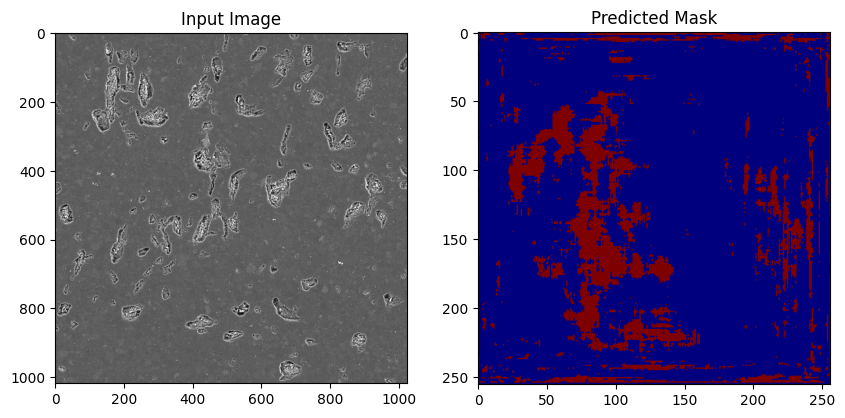

In [ ]:
def predict_mask(model, image_path):
    image = cv2.imread(image_path, cv2.IMREAD_UNCHANGED)

    if image.ndim == 3 and image.shape[2] == 4:
        image = cv2.cvtColor(image, cv2.COLOR_BGRA2GRAY)
    elif image.ndim == 3 and image.shape[2] == 3:
        image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    image = np.expand_dims(image, axis=-1).astype("float32") / 255.0

    dummy_mask = np.zeros((image.shape[0], image.shape[1]), dtype=np.uint8)
    augmented = val_transform(image=image, mask=dummy_mask)

    image_tensor = augmented["image"].unsqueeze(0).to(device)

    # Predict
    model.eval()
    with torch.no_grad():
        output = model(image_tensor)
        mask = torch.sigmoid(output)  # binary output
        mask = (mask > 0.5).long()
        mask = mask.squeeze(0).squeeze(0).cpu().numpy()

    return mask


test_img = "test/images/61620A_IP_09_53x35_12.tif"
pred_mask = predict_mask(model, test_img)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.title("Input Image")
plt.imshow(cv2.imread(test_img, cv2.IMREAD_UNCHANGED), cmap="gray")
plt.subplot(1,2,2)
plt.title("Predicted Mask")
plt.imshow(pred_mask, cmap="jet")
plt.show()